In [1]:
from sklearn.datasets import fetch_olivetti_faces
olivetti = fetch_olivetti_faces()
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [2]:
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [3]:
X = olivetti.data
y = olivetti.target

In [4]:
import numpy as np
np.sqrt(4096) , X.shape

(np.float64(64.0), (400, 4096))

In [5]:
round(X[-1].min()), round(X[-1].max())

(0, 1)

In [6]:
# 데이터 분할
from collections import Counter
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test \
    = train_test_split(X,y,test_size=0.4,stratify=y,random_state=42)

In [7]:
# 연산속도 높이기  PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99)
x_train_pca =  pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
pca.n_components_

np.int64(177)

In [8]:
# kmeans로 군집을 구분
# 최적의 k개수
# DBSCAN
# 계층적 군집화

In [9]:
# k평균 군집화
# OMP_NUM_THREADS=1  환경셋팅
import os
os.environ["OMP_NUM_THREADS"] = '1'

c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\c

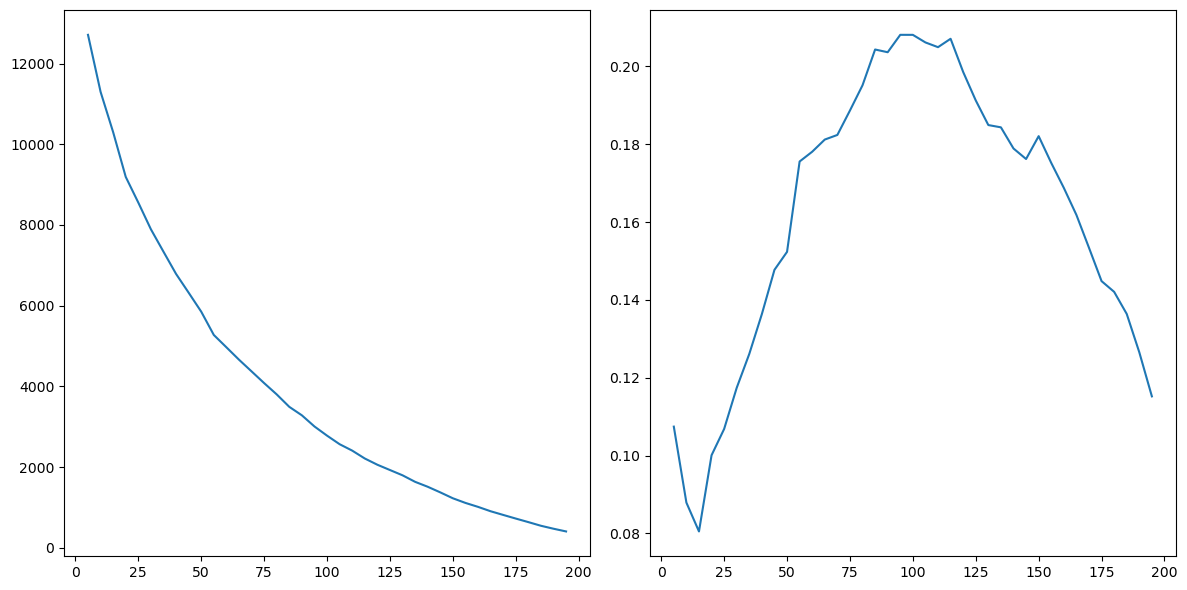

실루엣 최고점수의 인덱스 : 95


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
k_range = range(5,200,5)
ellow = []
sillhouet_scores = []
for k in k_range:
    km = KMeans(n_clusters=k,random_state=42)
    km.fit(x_train_pca)
    
    sillhouet_scores.append(silhouette_score(x_train_pca, km.labels_))
    ellow.append(km.inertia_)

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].plot(k_range,ellow )
ax[1].plot(k_range,sillhouet_scores)
plt.tight_layout()
plt.show()

print(f'실루엣 최고점수의 인덱스 : {k_range[np.argmax(sillhouet_scores)] }')

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

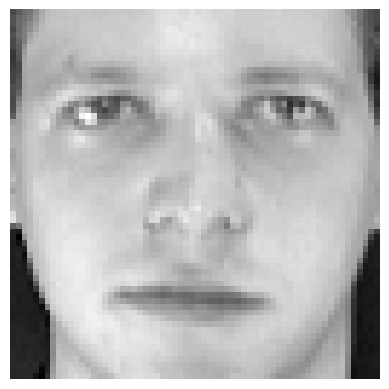

In [25]:
# 클러스터의 수 : 95
# 64 x 64
plt.imshow(X[0].reshape(64,64), cmap='gray')
plt.axis('off')

In [ ]:
cluster = 95 
from sklearn.cluster import KMeans
km = KMeans(n_clusters=cluster,random_state=42)
km.fit(x_train_pca)
# for cluster_id in np.unique(km.labels_):
#     cluster =  y[cluster_id == km.labels_]
#     print(cluster_id, len(cluster))
    
len(x_train_pca),len(y_train), len(km.labels_)

row_count = x_train[km.labels_ == 0].shape[0]

show_images = x_train[km.labels_ == 0]

for idx in range(1,row_count):
    plt.subplot(1,row_count,idx)
    plt.imshow(show_images[0].reshape(64,64),cmap='gray')    


1


c:\Users\Playdata\miniconda3\envs\base_stream\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
